
# P166246 Data Management Final Report (WIP)
### Matrix number: P166246
### Name: Muzaffar Izamuddin bin Daud


Data source is too big and is hosted in google drive in below link
The cells in this notebook will auto download the data files from google drive if no local folder exists
https://drive.google.com/drive/folders/1aO5fiudoif1c3bJO0atcvOXCllWwncHo?usp=sharing


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/P166246_Data_Management_Final_Report/blob/main/historical_AQI_data_combine.ipynb)

## Load, Combine And Clean Historical AQI Data

This step combines all CSV files from the `Raw_Data_Malaysia` folder into one dataset named `historical_AQI_data.csv`.

Cleaning actions performed:
- retain only Malaysia (`MY`) records prepared in `Raw_Data_Malaysia`
- remove metadata lines and repeated headers
- keep only the required AQI columns
- standardize text values by trimming spaces
- convert date and numeric columns into suitable data types
- remove incomplete rows and duplicate records
- sort the final dataset before saving for Hive upload


In [5]:
from pathlib import Path
import pandas as pd
import gdown

raw_data_folder = Path('Raw_Data_Malaysia')
output_file = Path('Malaysia_AQI_data_combined.csv')
drive_url = "https://drive.google.com/drive/folders/13768CUaNtEXynJq8dI85Z-PwPxHpVigk"

# Fallback Logic: If local folder doesn't exist, download from Drive
if not raw_data_folder.exists():
    print(f"'{raw_data_folder}' not found locally. Downloading from Google Drive...")
    gdown.download_folder(drive_url, output=str(raw_data_folder), quiet=False)
else:
    print(f"Using local files from: {raw_data_folder}")

csv_files = sorted(raw_data_folder.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No CSV files were found in {raw_data_folder}')

dataframes = []

expected_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']

for file in csv_files:
    df = pd.read_csv(file, comment='#', dtype=str)
    df.columns = df.columns.str.strip()
    df = df.dropna(how='all')
    df = df[expected_columns]
    dataframes.append(df)

historical_aqi_data = pd.concat(dataframes, ignore_index=True)

# Remove repeated header rows if they appear after combining files.
historical_aqi_data = historical_aqi_data[
    historical_aqi_data['Date'].astype(str).str.strip() != 'Date'
]

# Standardize text columns.
for column in ['Country', 'City', 'Specie']:
    historical_aqi_data[column] = historical_aqi_data[column].astype(str).str.strip()

# Convert columns to suitable data types.
historical_aqi_data['Date'] = pd.to_datetime(historical_aqi_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    historical_aqi_data[column] = pd.to_numeric(historical_aqi_data[column], errors='coerce')

# Remove incomplete or duplicated records.
historical_aqi_data = historical_aqi_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
historical_aqi_data = historical_aqi_data.drop_duplicates()
historical_aqi_data = historical_aqi_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
historical_aqi_data['Date'] = historical_aqi_data['Date'].dt.strftime('%Y-%m-%d')

#historical_aqi_data.to_csv(output_file, index=False) #not required as we want to combine with even more data

print(f'Combined {len(csv_files)} files into {output_file.name}')
print('Files included:')
for file in csv_files:
    print(f'- {file.name}')
print(f'Total cleaned rows: {len(historical_aqi_data):,}')
historical_aqi_data.head()


'Raw_Data_Malaysia' not found locally. Downloading from Google Drive...


Retrieving folder contents


Processing file 1cmMWt9LyiWK5BQs7Amm_RU17S9o0PQZg waqi-covid19-airqualitydata-2022Q1.csv
Processing file 1cC8q3F6iu4lUK7KIzDcf4ZhwqA6qw8LA waqi-covid19-airqualitydata-2022Q2.csv
Processing file 1oRRDb5V-sXXfigMv_ahjzRDZ5pYBAnE7 waqi-covid19-airqualitydata-2022Q3.csv
Processing file 1Tn-AxflpBt3i1fVoILff-KlaoVCiJkdb waqi-covid19-airqualitydata-2022Q4.csv
Processing file 1W_9YLftQyZS7mEZCJvHCixM2dh8AHnan waqi-covid19-airqualitydata-2023Q1.csv
Processing file 1cI2AVY_MjIeO_qSIhjRx_-jJtqj4ozVV waqi-covid19-airqualitydata-2023Q2.csv
Processing file 1i8KId_2Gs5JQ0tz-YGfH66ECVF8ch9Y2 waqi-covid19-airqualitydata-2023Q3.csv
Processing file 1QuQzUwwS29LrNLxrezE_ZCuXIuyakhTp waqi-covid19-airqualitydata-2023Q4.csv
Processing file 1ieXHzYk3NRrj0tGB7Lv4qtfU-4ruvN8D waqi-covid19-airqualitydata-2026.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1cmMWt9LyiWK5BQs7Amm_RU17S9o0PQZg
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia\waqi-covid19-airqualitydata-2022Q1.csv
100%|██████████| 56.0/56.0 [00:00<00:00, 430kB/s]
Downloading...
From: https://drive.google.com/uc?id=1cC8q3F6iu4lUK7KIzDcf4ZhwqA6qw8LA
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia\waqi-covid19-airqualitydata-2022Q2.csv
100%|██████████| 450k/450k [00:00<00:00, 10.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oRRDb5V-sXXfigMv_ahjzRDZ5pYBAnE7
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia\waqi-covid19-airqualitydata-2022Q3.csv
100%|██████████| 447k/447k [00:00<00:00, 15.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Tn-AxflpBt3i1fVoILff-KlaoVCiJk

Combined 9 files into Malaysia_AQI_data_combined.csv
Files included:
- waqi-covid19-airqualitydata-2022Q1.csv
- waqi-covid19-airqualitydata-2022Q2.csv
- waqi-covid19-airqualitydata-2022Q3.csv
- waqi-covid19-airqualitydata-2022Q4.csv
- waqi-covid19-airqualitydata-2023Q1.csv
- waqi-covid19-airqualitydata-2023Q2.csv
- waqi-covid19-airqualitydata-2023Q3.csv
- waqi-covid19-airqualitydata-2023Q4.csv
- waqi-covid19-airqualitydata-2026.csv
Total cleaned rows: 114,218


,Date,Country,City,Specie,count,min,max,median,variance
0,2022-03-28,MY,Alor Setar,aqi,42,32.0,47.0,37.0,205.60
1,2022-03-28,MY,Alor Setar,dew,42,24.0,27.0,25.0,8.08
2,2022-03-28,MY,Alor Setar,humidity,48,66.0,100.0,88.0,1074.26
3,2022-03-28,MY,Alor Setar,pressure,48,1006.0,1012.0,1010.0,31.47
4,2022-03-28,MY,Alor Setar,temperature,48,25.0,33.0,27.0,78.87


In [6]:
historical_aqi_data.City.value_counts()

City
Malacca         9589
Kuala Lumpur    9357
Klang           9310
Alor Setar      8929
Kuantan         8746
Kota Bharu      8713
George Town     8623
Kuching         8554
Johor Bahru     8547
Seremban        8528
Taiping         8448
Ipoh            8441
Miri            8433
Name: count, dtype: int64

In [7]:
historical_aqi_data.Specie.value_counts()


Specie
pressure         17108
humidity         17108
temperature      17108
wind-speed       17108
dew              17102
aqi              15897
wind-gust         4698
pm10              1248
pm25              1248
no2               1244
so2               1244
co                1243
o3                1243
precipitation      619
Name: count, dtype: int64

In [8]:

# Need to run previous cell as data is appended onto previous data
base_data = historical_aqi_data.copy()

raw_data_folder_2 = Path('Raw_Data_Malaysia_2')
output_file = Path('Malaysia_AQI_data_combined.csv')
drive_url_2 = "https://drive.google.com/drive/folders/1obiJMmGTdbST1g0hdNzVJND9SLCBi7Fd"

# --- Fallback Clause ---
if not raw_data_folder_2.exists():
    print(f"'{raw_data_folder_2}' not found locally. Downloading from Google Drive...")
    gdown.download_folder(drive_url_2, output=str(raw_data_folder_2), quiet=False)
else:
    print(f"Using local files from: {raw_data_folder_2}")

csv_files_2 = sorted(raw_data_folder_2.glob('*.csv'))

if not csv_files_2:
    raise FileNotFoundError(f'No CSV files were found in {raw_data_folder_2}')

expected_base_columns = ['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median', 'variance']
base_data.columns = base_data.columns.str.strip()
base_data = base_data[expected_base_columns].copy()

def city_from_filename(file_path: Path) -> str:
    name = file_path.stem.replace('-air-quality', '').strip()
    city = name.split(',')[0].strip(' -')
    return city.title()

extra_frames = []
for file in csv_files_2:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lower()

    if 'date' not in df.columns:
        continue

    pollutant_columns = [c for c in df.columns if c not in ['date']]
    melted = df.melt(id_vars='date', value_vars=pollutant_columns, var_name='Specie', value_name='value')

    melted['Date'] = pd.to_datetime(melted['date'], errors='coerce')
    melted['value'] = pd.to_numeric(melted['value'], errors='coerce')
    melted = melted.dropna(subset=['Date', 'value'])

    if melted.empty:
        continue

    city_name = city_from_filename(file)
    transformed = pd.DataFrame({
        'Date': melted['Date'],
        'Country': 'Malaysia',
        'City': city_name,
        'Specie': melted['Specie'].astype(str).str.strip().str.lower(),
        'count': 1,
        'min': melted['value'],
        'max': melted['value'],
        'median': melted['value'],
        'variance': 0
    })
    extra_frames.append(transformed)

if not extra_frames:
    raise ValueError('Raw_Data_Malaysia_2 files were read, but no valid rows were produced.')

extra_data = pd.concat(extra_frames, ignore_index=True)
combined_data = pd.concat([base_data, extra_data], ignore_index=True)

for column in ['Country', 'City', 'Specie']:
    combined_data[column] = combined_data[column].astype(str).str.strip()

combined_data['Date'] = pd.to_datetime(combined_data['Date'], errors='coerce')
for column in ['count', 'min', 'max', 'median', 'variance']:
    combined_data[column] = pd.to_numeric(combined_data[column], errors='coerce')

combined_data = combined_data.dropna(subset=['Date', 'Country', 'City', 'Specie'])
combined_data = combined_data.drop_duplicates()
combined_data = combined_data.sort_values(['Date', 'Country', 'City', 'Specie']).reset_index(drop=True)
combined_data['Date'] = combined_data['Date'].dt.strftime('%Y-%m-%d')

combined_data.to_csv(output_file, index=False, header=False)

print(f'Added city files: {len(csv_files_2)}')
print(f'Rows from Raw_Data_Malaysia_2: {len(extra_data):,}')
print(f'Total rows in combined file: {len(combined_data):,}')
print(f'Output: {output_file.name}')
combined_data.head()


'Raw_Data_Malaysia_2' not found locally. Downloading from Google Drive...


Retrieving folder contents


Processing file 1z1ITM0WH5SUu393x2L99nFZfHlcoE0Is alor-gajah, melaka-air-quality.csv
Processing file 1S59UBsXdmpXZWgGmKdC_VZZFH4F46xdC alor-setar, kedah-air-quality.csv
Processing file 1v5Q2NakTAxs2w1zircRRTwpbUp1WfkHn bakar-arang, sg. petani, kedah-air-quality.csv
Processing file 1y8oGa1njGxwYK9UbLxJeXpuurEinG_jR balik-pulau, pulau pinang-air-quality.csv
Processing file 1L27qKTaBgSASGUsrbvQCsAuQrWQAhedj balok-baru, kuantan, pahang-air-quality.csv
Processing file 1cVDM0yw216fGw0lrnllWpbZqabGIevB3 bandaraya-melaka, melaka-air-quality.csv
Processing file 16jSshYkeMpBIBVDa3_OPVTHjA1ZRz3WV banting,-selangor-air-quality.csv
Processing file 1PluSep6WbZobjws6h8qttsZOE0zT2iZX batu-muda,kuala lumpur, wilayah persekutuan-air-quality.csv
Processing file 1TgrSwxDNUTGxUXxiD04B9nbXc8ky96zh batu-pahat, johor-air-quality.csv
Processing file 1G0T2E15mjlvxzoP-Gd_BJamYYc6iuGqA bukit-rambai, melaka-air-quality.csv
Processing file 1jynJ5KdYTwvbnijTB4yNuS0t_7OAyC8x cheras,kuala-lumpur, wilayah persekutuan-a

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1z1ITM0WH5SUu393x2L99nFZfHlcoE0Is
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia_2\alor-gajah, melaka-air-quality.csv
100%|██████████| 52.8k/52.8k [00:00<00:00, 7.41MB/s]
Downloading...
From: https://drive.google.com/uc?id=1S59UBsXdmpXZWgGmKdC_VZZFH4F46xdC
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia_2\alor-setar, kedah-air-quality.csv
100%|██████████| 107k/107k [00:00<00:00, 5.51MB/s]
Downloading...
From: https://drive.google.com/uc?id=1v5Q2NakTAxs2w1zircRRTwpbUp1WfkHn
To: c:\Users\PC 14\Desktop\github - muz\P166246_Data_Management_Final_Report\Raw_Data_Malaysia_2\bakar-arang, sg. petani, kedah-air-quality.csv
100%|██████████| 108k/108k [00:00<00:00, 3.65MB/s]
Downloading...
From: https://drive.google.com/uc?id=1y8oGa1njGxwYK9UbLxJeXp

Added city files: 42
Rows from Raw_Data_Malaysia_2: 162,410
Total rows in combined file: 276,628
Output: Malaysia_AQI_data_combined.csv


,Date,Country,City,Specie,count,min,max,median,variance
0,2014-01-01,Malaysia,Alor-Setar,aqi,1,34.0,34.0,34.0,0.0
1,2014-01-01,Malaysia,Bakar-Arang,aqi,1,55.0,55.0,55.0,0.0
2,2014-01-01,Malaysia,Balok-Baru,aqi,1,40.0,40.0,40.0,0.0
3,2014-01-01,Malaysia,Bandaraya-Melaka,aqi,1,29.0,29.0,29.0,0.0
4,2014-01-01,Malaysia,Banting,aqi,1,41.0,41.0,41.0,0.0


In [9]:
#use pivot table to check available dates for pm25,pm10, no2 and co (major pollutants)
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

date_range_pivot = combined_data.pivot_table(
    index=['City', 'Specie'], 
    values='Date', 
    aggfunc=['min', 'max']
)
date_range_pivot.columns = ['Start Date', 'End Date']
target_species = ['pm25', 'pm10', 'no2', 'co']
filtered_pivot = date_range_pivot.query("Specie in @target_species")

# ensure display does not truncate the output
pd.set_option('display.max_rows', None)

print(filtered_pivot)

                        Start Date   End Date
City             Specie                      
Alor Setar       co     2025-07-28 2025-10-31
                 no2    2025-07-28 2025-10-31
                 pm10   2025-07-28 2025-10-31
                 pm25   2025-07-28 2025-10-31
Alor-Gajah       pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Alor-Setar       no2    2025-07-27 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Bakar-Arang      no2    2025-07-27 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Balik-Pulau      no2    2025-07-27 2025-10-29
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Balok-Baru       no2    2025-07-29 2025-10-30
                 pm10   2025-07-27 2025-10-30
                 pm25   2025-07-28 2025-10-31
Bandaraya-Melaka no2    2025-07-27 2025-10-30
                 pm10   2025-07-27

In [10]:
combined_data.Specie.value_counts()

Specie
aqi              163358
humidity          17108
temperature       17108
pressure          17108
wind-speed        17108
dew               17102
pm10               5280
pm25               5280
wind-gust          4698
o3                 4407
no2                4352
so2                1857
co                 1243
precipitation       619
Name: count, dtype: int64

In [11]:
combined_data.isnull().sum()

Date        0
Country     0
City        0
Specie      0
count       0
min         0
max         0
median      0
variance    0
dtype: int64

In [12]:
#this cell is a helper function to show images from github
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

def show_github_img(repo_path):
    """Fetches and displays an image directly from your GitHub repo."""
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/"
    full_url = base_url + repo_path
    
    try:
        response = requests.get(full_url)
        img = Image.open(BytesIO(response.content))
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error loading image from {full_url}: {e}")

Next I used Ambari hive view to upload table and explore the data before going further

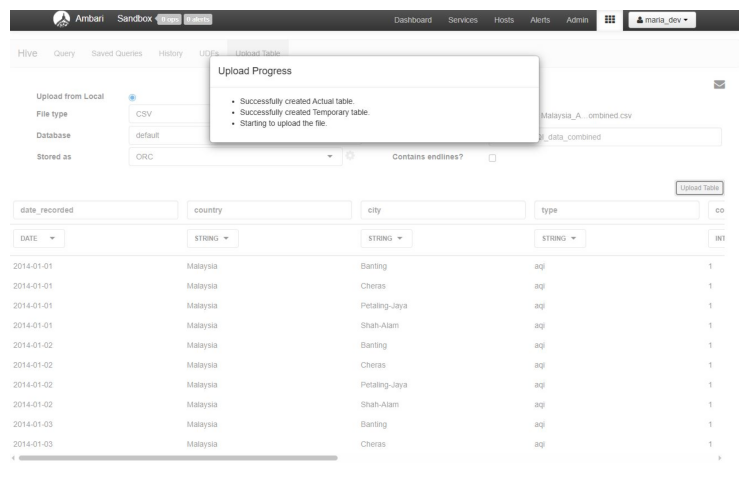

In [13]:
show_github_img("images/upload_table.JPG")

Example Hive data filtering as below image

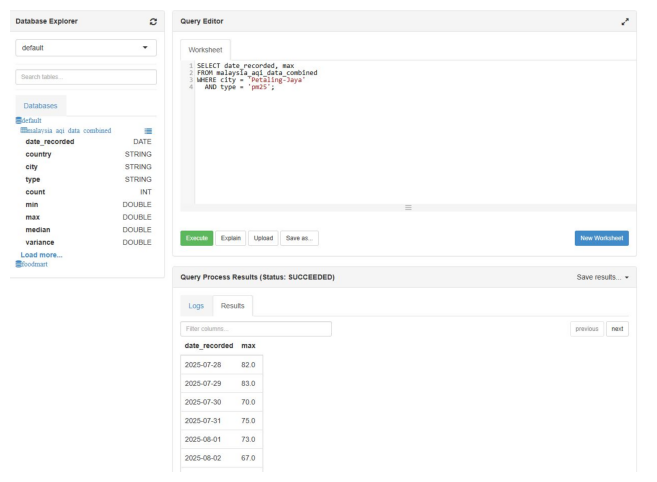

In [ ]:
show_github_img("images/pm25_petaling_jaya.JPG")

I then use Hive to understand the cities with top pollution in Malaysia using:
#### top_10pm25.hive

The code inside this script can be changed to output either pm25,pm10,no2 or co

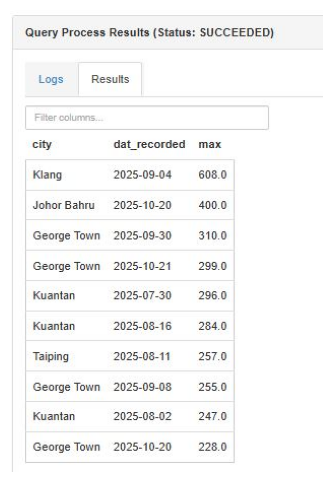

In [ ]:
show_github_img("images/top10_pm25.JPG")

We then use Hive to understand create a list of cities available in the data pool:
#### Unique_cities.hive

The output is saved in 
#### output_city.txt

I then upload combine_data into ambari using File view then use Pig to filter down to specific pollutant (PM2.5 only)

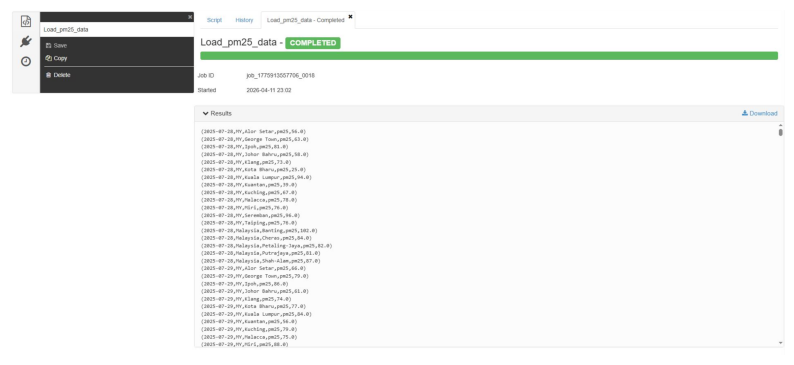

In [ ]:

show_github_img("images/pig_success.JPG")

The data output from Pig are pm10_only_pigoutput, pm25_only_pigoutput, no2_only_pigoutput and co_only_pigoutput.
The data is then saved into github for easier recalling

In [14]:
import pandas as pd
import os

# Define file info
file_name = 'pm25_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_pm25 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub (Colab Mode) ---")
    df_pm25 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_pm25['date_recorded'] = pd.to_datetime(df_pm25['date_recorded'])

df_pm25.head()

--- Loading pm25_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,pm25,56.0
1,2025-07-28,MY,George Town,pm25,63.0
2,2025-07-28,MY,Ipoh,pm25,81.0
3,2025-07-28,MY,Johor Bahru,pm25,58.0
4,2025-07-28,MY,Klang,pm25,73.0


In [15]:
#use plotly for interactive plot since many data is plotted at once
import plotly.express as px

fig = px.line(df_pm25, 
              x="date_recorded", 
              y="median", 
              color="city",
              title="PM2.5 Levels by City: July - Oct 2025",
              labels={"median": "PM2.5 Concentration", "date_recorded": "Date"})

fig.update_layout(hovermode="x unified") # Shows all values for a date when hovering
fig.show()

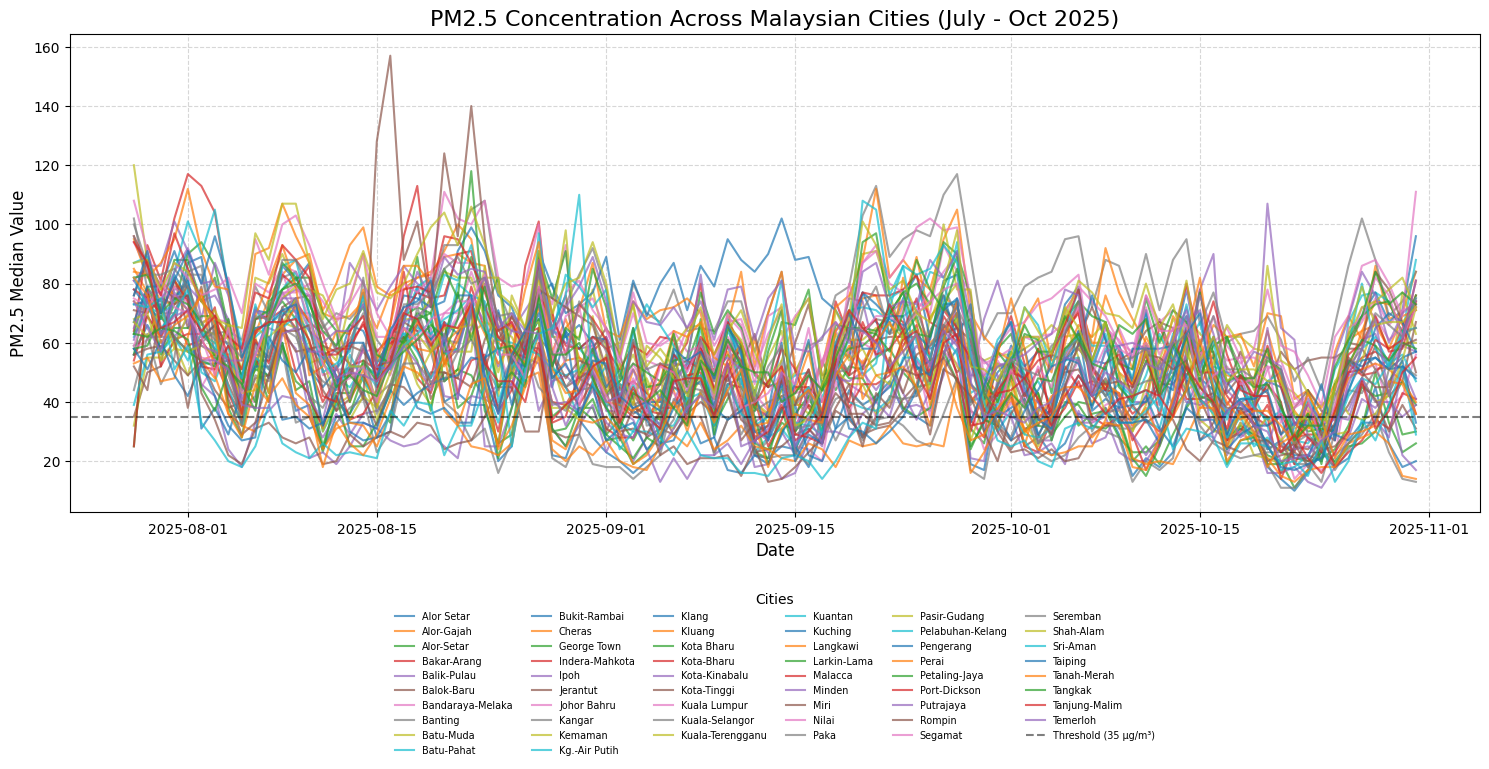

In [16]:
#matplotlib version plotting with addition of WHO threshold
# 1. Prepare data
df_pm25['date_recorded'] = pd.to_datetime(df_pm25['date_recorded'])
df_pm25 = df_pm25.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))

# 3. Plot each city
for city in df_pm25['city'].unique():
    city_data = df_pm25[df_pm25['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM2.5 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=35, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('PM2.5 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(
    title="Cities", 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Moves legend below the X-axis
    fontsize='x-small', 
    ncol=6,                      # Split into 6 columns
    frameon=False
)
plt.tight_layout()
plt.show()

From the plot, there was several findings:
1) It was found that there is a peak in high PM2.5 reading in September 15 2025 - October 1 2025 through out the 18 cities. It is suspected that this is the haze season where higher air quality readings are observed
2) Almost all areas are above the recommended safe air quality level of 35ugm3. Malaysia actually does not have a very good air quality level and can be improved
3) Peak of PM2.5 is observed on september 27

In [17]:
# Define file info
file_name = 'pm10_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_pm10 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_pm10 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_pm10['date_recorded'] = pd.to_datetime(df_pm10['date_recorded'])

df_pm10.head()

--- Loading pm10_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-27,Malaysia,Alor-Gajah,pm10,34.0
1,2025-07-27,Malaysia,Alor-Setar,pm10,23.0
2,2025-07-27,Malaysia,Bakar-Arang,pm10,27.0
3,2025-07-27,Malaysia,Balik-Pulau,pm10,25.0
4,2025-07-27,Malaysia,Balok-Baru,pm10,16.0


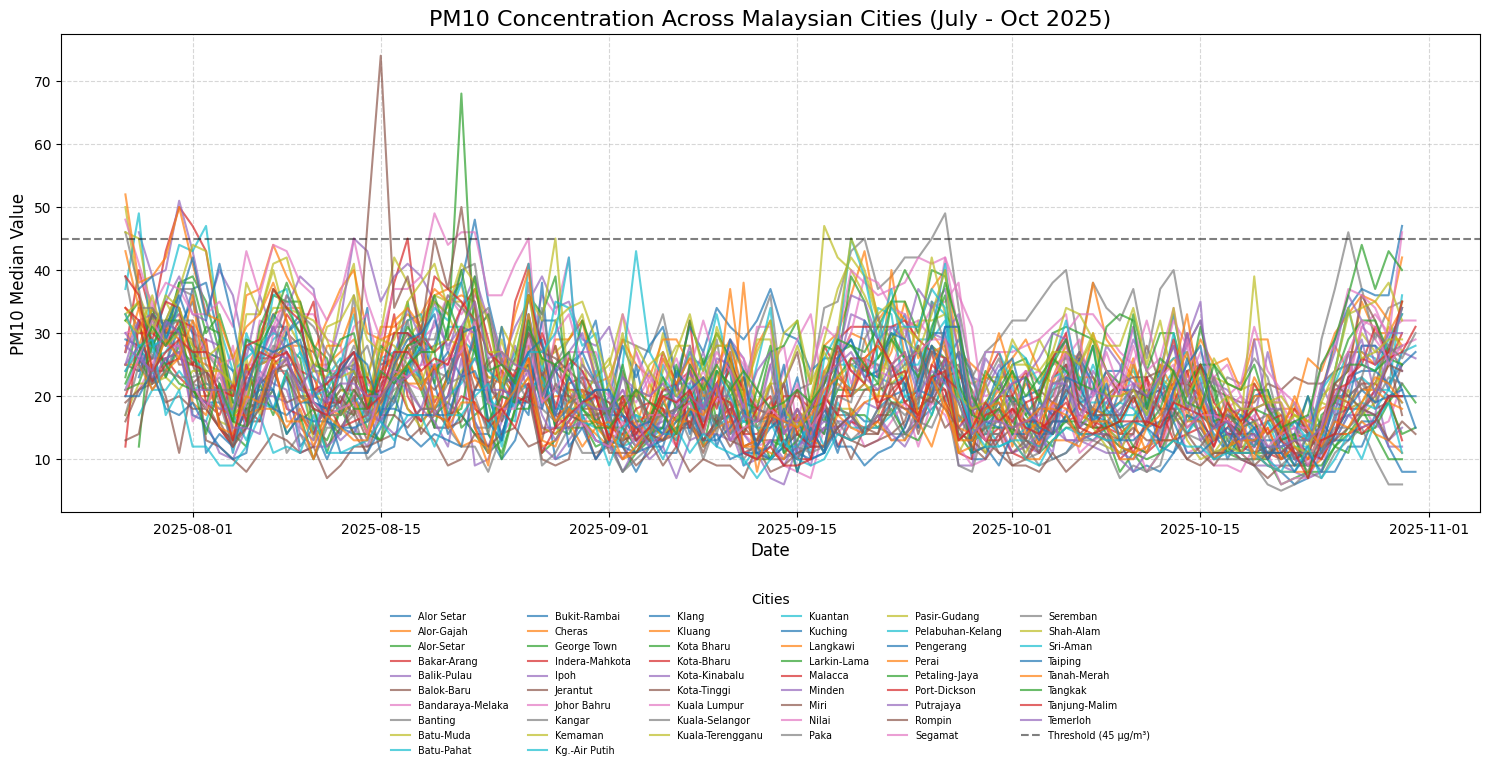

In [18]:
#plot pm10 data
# 1. Prepare data
df_pm10['date_recorded'] = pd.to_datetime(df_pm10['date_recorded'])
df_pm10 = df_pm10.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))

# 3. Plot each city
for city in df_pm10['city'].unique():
    city_data = df_pm10[df_pm10['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM2.5 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=45, color='black', linestyle='--', alpha=0.5, label='Threshold (45 µg/m³)')

# 5. Labels and Styling
plt.title('PM10 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM10 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(
    title="Cities", 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Moves legend below the X-axis
    fontsize='x-small', 
    ncol=6,                      # Split into 6 columns
    frameon=False
)
plt.tight_layout()
plt.show()

Next we add data for co and no2 - these are two more pollutant that is popular when analyzing air quality
Load_co_data.pig and Load_no2_data.pig is run in VM / Ambari
then output is saved as co_only_pigoutput and no2_only_pigoutput

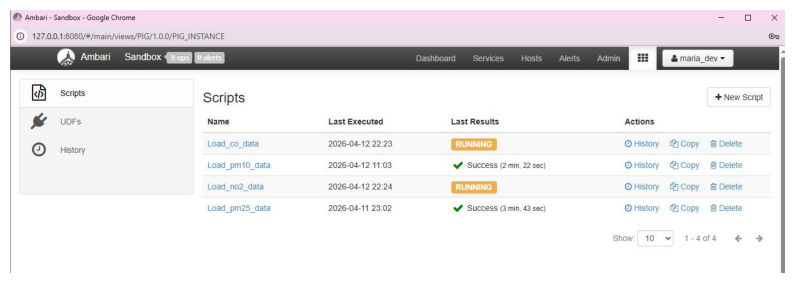

In [19]:
show_github_img("images/co_no2_pigrunning.JPG")

In [20]:
# Define file info
file_name = 'no2_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_no2 = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_no2 = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_no2['date_recorded'] = pd.to_datetime(df_no2['date_recorded'])

df_no2.head()

--- Loading no2_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-27,Malaysia,Alor-Setar,no2,4.0
1,2025-07-27,Malaysia,Bakar-Arang,no2,3.0
2,2025-07-27,Malaysia,Balik-Pulau,no2,3.0
3,2025-07-27,Malaysia,Bandaraya-Melaka,no2,3.0
4,2025-07-27,Malaysia,Banting,no2,8.0


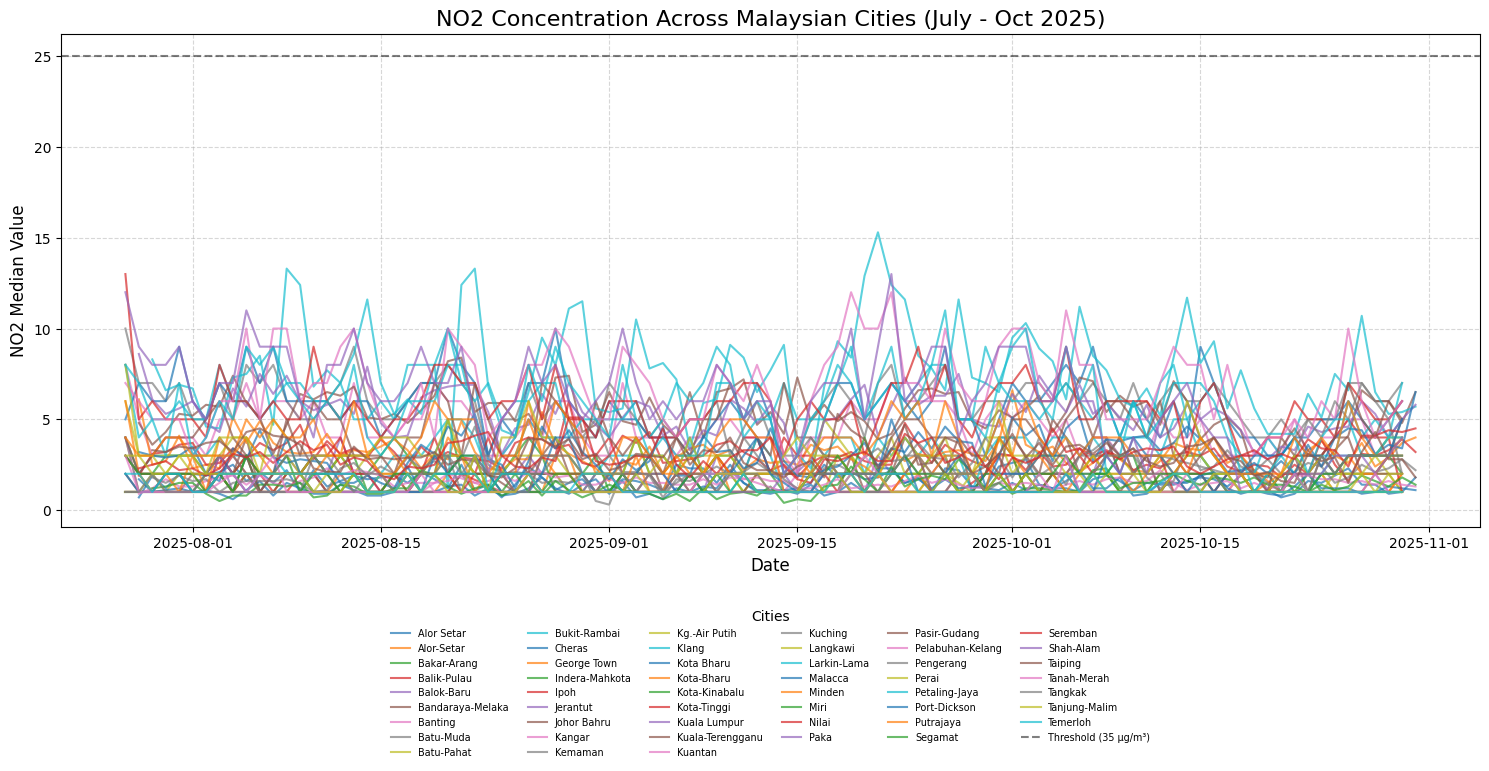

In [21]:
#plot no2 data
df_no2['date_recorded'] = pd.to_datetime(df_no2['date_recorded'])
df_no2 = df_no2.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))
# 3. Plot each city
for city in df_no2['city'].unique():
    city_data = df_no2[df_no2['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM10 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=25, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('NO2 Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('NO2 Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(
    title="Cities", 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Moves legend below the X-axis
    fontsize='x-small', 
    ncol=6,                      # Split into 6 columns
    frameon=False
)
plt.tight_layout()
plt.show()

In [22]:
# Define file info
file_name = 'co_only_pigoutput.csv'
column_names = ['date_recorded', 'country', 'city', 'type', 'median']
github_raw_url = f'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/{file_name}'

# Fallback Logic: Check if file exists locally, otherwise pull from GitHub
if os.path.exists(file_name):
    print(f"--- Loading {file_name} from local directory ---")
    df_co = pd.read_csv(file_name, names=column_names)
else:
    print(f"--- Local file not found. Pulling {file_name} from GitHub ---")
    df_co = pd.read_csv(github_raw_url, names=column_names)

# Ensure date is in datetime format for your plots
df_co['date_recorded'] = pd.to_datetime(df_co['date_recorded'])

df_co.head()

--- Loading co_only_pigoutput.csv from local directory ---


,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,co,0.1
1,2025-07-28,MY,George Town,co,0.1
2,2025-07-28,MY,Ipoh,co,0.1
3,2025-07-28,MY,Johor Bahru,co,0.1
4,2025-07-28,MY,Kota Bharu,co,0.1


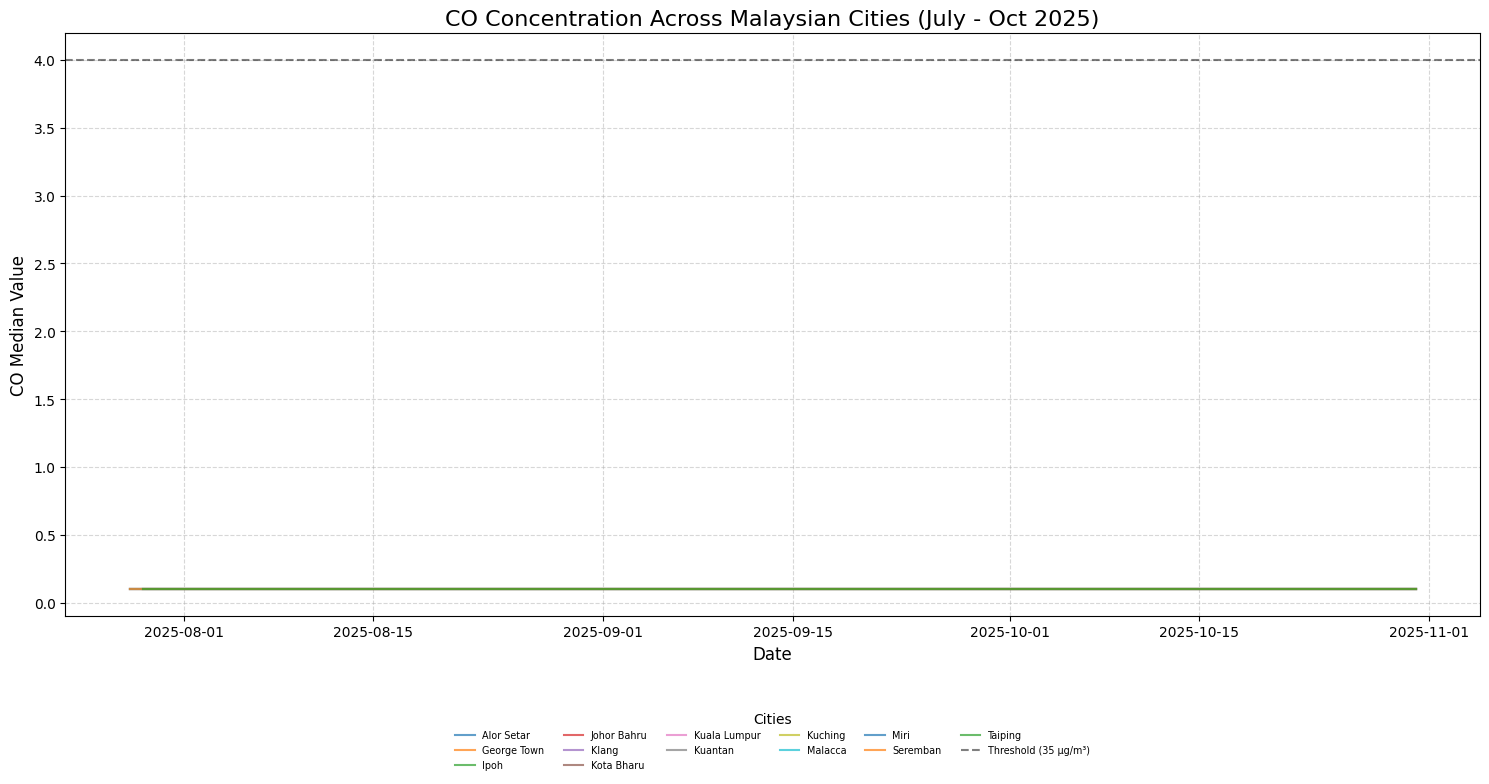

In [23]:
#plot co data
df_co['date_recorded'] = pd.to_datetime(df_co['date_recorded'])
df_co = df_co.sort_values(['city', 'date_recorded'])

# 2. Setup the plot
plt.figure(figsize=(15, 8))
# 3. Plot each city
for city in df_co['city'].unique():
    city_data = df_co[df_co['city'] == city]
    plt.plot(city_data['date_recorded'], 
             city_data['median'], 
             label=city, 
             linewidth=1.5, 
             alpha=0.7)

# 4. Add a horizontal line for the WHO / Malaysian API 'Unhealthy' threshold 
# PM10 threshold for 'Unhealthy' is often cited around 35-55 µg/m³ depending on the standard
plt.axhline(y=4, color='black', linestyle='--', alpha=0.5, label='Threshold (35 µg/m³)')

# 5. Labels and Styling
plt.title('CO Concentration Across Malaysian Cities (July - Oct 2025)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('CO Median Value', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Move legend outside the plot
plt.legend(
    title="Cities", 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), # Moves legend below the X-axis
    fontsize='x-small', 
    ncol=6,                      # Split into 6 columns
    frameon=False
)
plt.tight_layout()
plt.show()

What we see from the four plots:
1. Only PM2.5 concentration levels is above the recommended healthy limit stipulated by WHO at 35u g/m^3
2. CO is very low, almost non existant
3. NO2 is alse quite low. Readings range between 0-15u g/m^3 and is within safe limits
4. PM10 only has 1 spike above the recommended limit

Next, we will focus our analysis on PM2.5 as this is shown to be the main pollutant that has consistently exceeded the safe limits
We want to plot the pm2.5 readings on a map to see which areas are highly polluted.

In [24]:
df_pm25.head()

,date_recorded,country,city,type,median
0,2025-07-28,MY,Alor Setar,pm25,56.0
55,2025-07-29,MY,Alor Setar,pm25,66.0
110,2025-07-30,MY,Alor Setar,pm25,58.0
165,2025-07-31,MY,Alor Setar,pm25,66.0
220,2025-08-01,MY,Alor Setar,pm25,87.0


In [25]:
#Data cleaning
# 1. Standardize Malaysia spelling
df_pm25['country'] = df_pm25['country'].replace('MY', 'Malaysia')

# 2. Standardize City names (Replace hyphens with spaces and remove extra whitespace)
df_pm25['city'] = df_pm25['city'].str.replace('-', ' ').str.strip()

# 3. Convert date_recorded to datetime objects
df_pm25['date_recorded'] = pd.to_datetime(df_pm25['date_recorded'])

# 4. Handle duplicates created by name cleaning
# We group by date and city and take the mean of the median AQI values
df_pm25 = df_pm25.groupby(['date_recorded', 'country', 'city', 'type'], as_index=False)['median'].mean()

# 5. Final Check
print(f"Data cleaned. Current row count: {len(df_pm25)}")
print(df_pm25.head())

Data cleaned. Current row count: 5088
  date_recorded   country         city  type  median
0    2025-07-28  Malaysia   Alor Gajah  pm25    85.0
1    2025-07-28  Malaysia   Alor Setar  pm25    56.0
2    2025-07-28  Malaysia  Bakar Arang  pm25    64.0
3    2025-07-28  Malaysia  Balik Pulau  pm25    63.0
4    2025-07-28  Malaysia   Balok Baru  pm25    35.0


In [27]:
import pandas as pd
from geopy.geocoders import ArcGIS
from geopy.extra.rate_limiter import RateLimiter

# Check if df_final already exists and has the required columns
if 'df_final' in locals() and 'latitude' in df_final.columns and 'longitude' in df_final.columns:
    print("Coordinates already exist in df_final. Skipping geocoding to save time.")
else:
    # 1. Initialize ArcGIS
    geolocator = ArcGIS(timeout=10)
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=0.2)

    # 2. Get the unique cities
    unique_cities = df_pm25[['city', 'country']].drop_duplicates().copy()
    unique_cities['address'] = unique_cities['city'] + ', ' + unique_cities['country']

    # 3. Geocode only the unique names
    print(f"Geocoding {len(unique_cities)} unique cities...")
    unique_cities['location'] = unique_cities['address'].apply(geocode)
    unique_cities['latitude'] = unique_cities['location'].apply(lambda loc: loc.latitude if loc else None)
    unique_cities['longitude'] = unique_cities['location'].apply(lambda loc: loc.longitude if loc else None)

    # --- THE FIX ---
    # Drop latitude/longitude from df_pm25 if they already exist to avoid _x and _y suffixes
    cols_to_drop = [c for c in ['latitude', 'longitude', 'address', 'location'] if c in df_pm25.columns]
    df_pm25_clean = df_pm25.drop(columns=cols_to_drop)

    # 4. Merge back to get clean 'latitude' and 'longitude' columns
    df_final = df_pm25_clean.merge(
        unique_cities[['city', 'country', 'latitude', 'longitude']], 
        on=['city', 'country'], 
        how='left'
    )
    print("Done! Geocoding complete and coordinates assigned to df_final.")

print(df_final.head())

Geocoding 53 unique cities...
Done! Geocoding complete and coordinates assigned to df_final.
  date_recorded   country         city  type  median  latitude   longitude
0    2025-07-28  Malaysia   Alor Gajah  pm25    85.0  2.383392  102.209564
1    2025-07-28  Malaysia   Alor Setar  pm25    56.0  6.121073  100.369800
2    2025-07-28  Malaysia  Bakar Arang  pm25    64.0  5.666670  100.366670
3    2025-07-28  Malaysia  Balik Pulau  pm25    63.0  5.353636  100.234096
4    2025-07-28  Malaysia   Balok Baru  pm25    35.0  3.923600  103.375000


Loading shapefile from local directory.


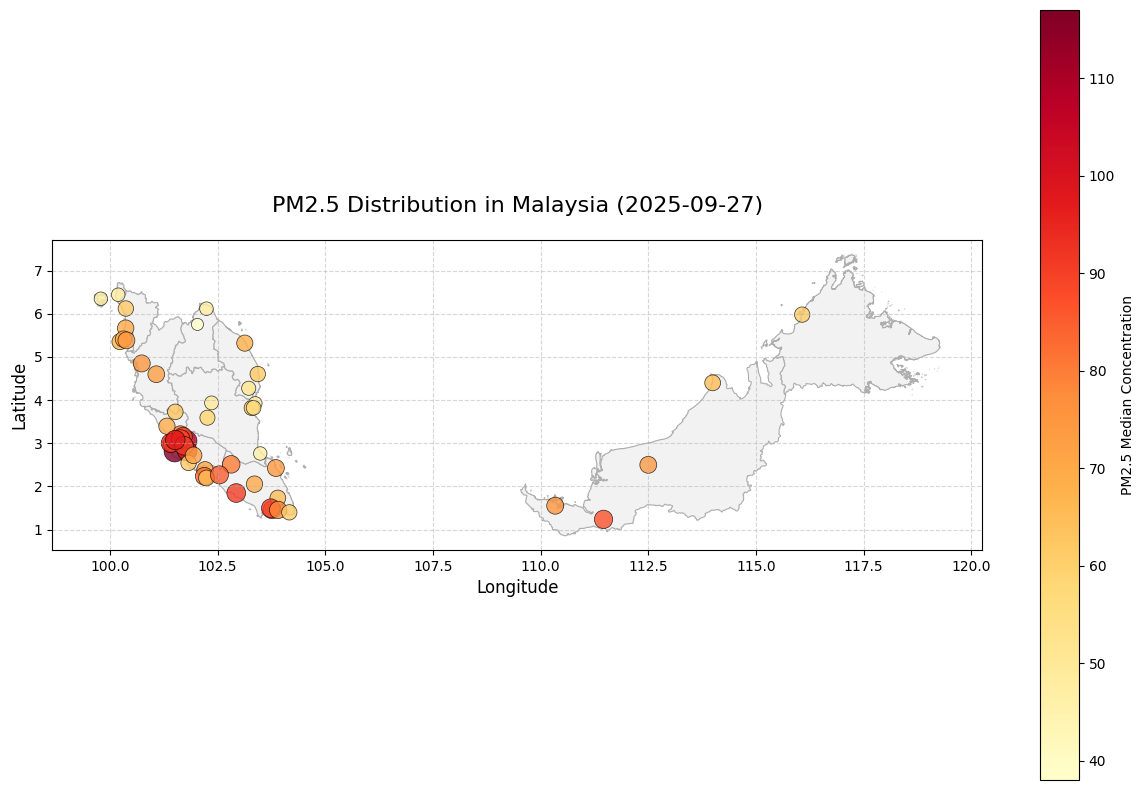

In [ ]:
import os
import requests
import geopandas as gpd

def load_malaysia_map():
    local_file = 'mys_admin1.shp'
    
    extensions = ['.shp', '.shx', '.dbf', '.prj', '.cpg']
    base_url = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Data_Management_Final_Report/main/map/mys_admin1"

    # Check if the main .shp file exists locally
    if not os.path.exists(local_file):
        print("Shapefile not found locally. Downloading from GitHub...")
        for ext in extensions:
            target_url = base_url + ext
            response = requests.get(target_url)
            
            if response.status_code == 200:
                with open(f'mys_admin1{ext}', 'wb') as f:
                    f.write(response.content)
                print(f"Successfully downloaded: mys_admin1{ext}")
            else:
                print(f"Failed to download {ext}. Status code: {response.status_code}")
    else:
        print("Loading shapefile from local directory.")

    return gpd.read_file(local_file)

#save malaysia map shapefile locally
malaysia_map = load_malaysia_map()

# 2. Filter for your specific date
target_date = '2025-09-27'
df_sept27 = df_final[df_final['date_recorded'] == target_date].copy()

# 3. Create GeoDataFrame
gdf_pm25 = gpd.GeoDataFrame(
    df_sept27, 
    geometry=gpd.points_from_xy(df_sept27.longitude, df_sept27.latitude),
    crs="EPSG:4326"
)

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 10))
malaysia_map.plot(ax=ax, color='#f2f2f2', edgecolor='#adadad', linewidth=0.8)

# Plot the PM2.5 points
scatter = gdf_pm25.plot(
    ax=ax, 
    column='median', 
    cmap='YlOrRd', 
    markersize=df_sept27['median'] * 2, 
    legend=True, 
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': "PM2.5 Median Concentration"}
)

# --- AXIS & LABELS ---
ax.set_axis_on() # Ensure the axes are visible
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5) # Add a grid for easier coordinate reading

plt.title(f"PM2.5 Distribution in Malaysia ({target_date})", fontsize=16, pad=20)

plt.show()

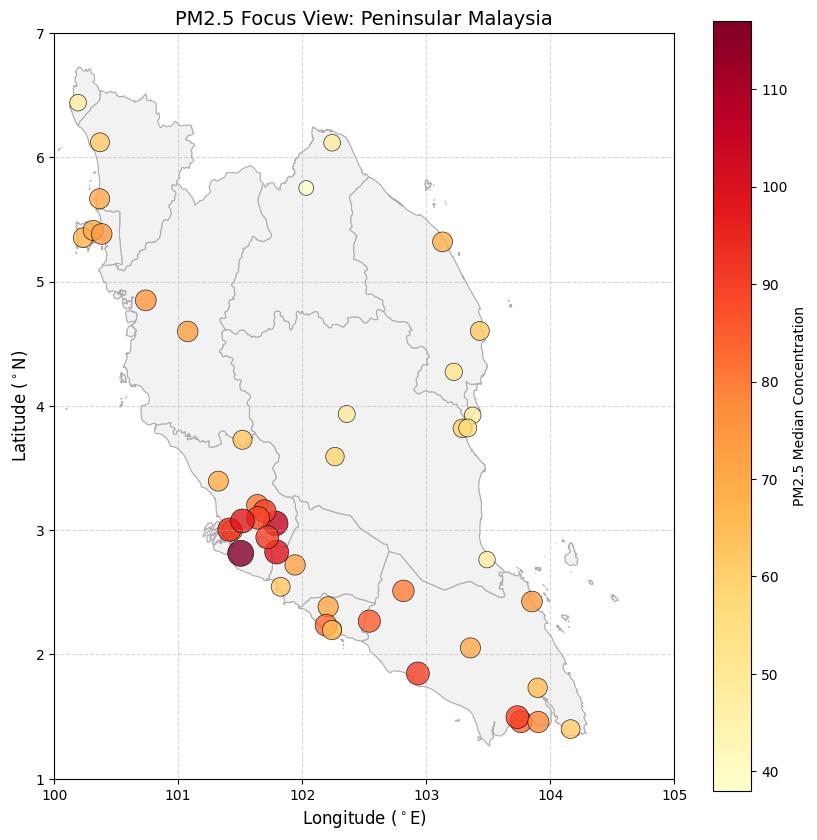

In [30]:
# This cell assumes 'malaysia_map' and 'gdf_pm25' were defined in the previous cell
fig, ax = plt.subplots(figsize=(10, 10))

malaysia_map.plot(ax=ax, color='#f2f2f2', edgecolor='#adadad', linewidth=0.8)

gdf_pm25.plot(
    ax=ax, 
    column='median', 
    cmap='YlOrRd', 
    markersize=gdf_pm25['median'] * 3, # Dot size scales with values
    legend=True, 
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': "PM2.5 Median Concentration"}
)

# 3. Focus/Crop the view
ax.set_xlim([100, 105])
ax.set_ylim([1, 7])

# 4. Axes and labels (using raw strings 'r' to avoid SyntaxWarnings)
ax.set_axis_on()
ax.set_xlabel(r"Longitude ($^\circ$E)", fontsize=12)
ax.set_ylabel(r"Latitude ($^\circ$N)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.title("PM2.5 Focus View: Peninsular Malaysia", fontsize=14)
plt.show()

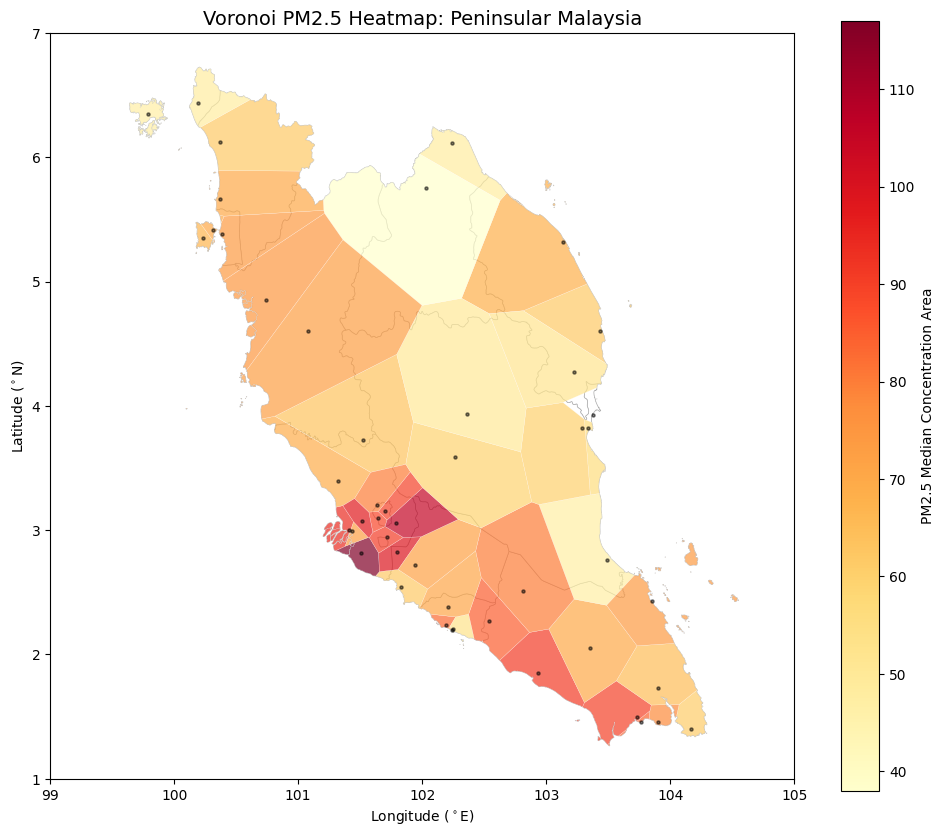

In [32]:
# Use Voronoi method to fill in the spaces between known air quality measurement points
# #import matplotlib.pyplot as plt
from shapely.ops import unary_union
from shapely.geometry import MultiPoint
from geopandas.tools import overlay
import numpy as np

# 1. Create a boundary for the Voronoi (the union of Malaysia)
# This prevents the Voronoi cells from extending to infinity
malaysia_boundary = unary_union(malaysia_map.geometry)

# 2. Generate Voronoi Polygons from your GeoDataFrame points
coords = np.array(list(gdf_pm25.geometry.apply(lambda x: (x.x, x.y))))
points = MultiPoint(coords)

# Create the Voronoi cells
from shapely.ops import voronoi_diagram
vor_polys = voronoi_diagram(points)

# 3. Convert Voronoi to a GeoDataFrame
import geopandas as gpd
gdf_vor = gpd.GeoDataFrame(geometry=[p for p in vor_polys.geoms], crs=gdf_pm25.crs)

# 4. Clip the Voronoi cells to the Malaysia map shape
gdf_vor_clipped = gpd.clip(gdf_vor, malaysia_map)

# 5. Spatial Join to attach PM2.5 values to the Voronoi cells
# This gives each "cell" the median value of the point inside it
gdf_vor_final = gpd.sjoin(gdf_vor_clipped, gdf_pm25[['median', 'geometry']], how='left', predicate='contains')

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the base map for context
malaysia_map.plot(ax=ax, color='white', edgecolor='#adadad', linewidth=0.5)

# Plot the Voronoi Heatmap
gdf_vor_final.plot(
    ax=ax, 
    column='median', 
    cmap='YlOrRd', 
    legend=True, 
    alpha=0.7,
    edgecolor='white', # Set to 'none' for a smoother heatmap look
    linewidth=0.2,
    legend_kwds={'label': "PM2.5 Median Concentration Area"}
)

# Optional: Overlay the original points to show station locations
gdf_pm25.plot(ax=ax, marker='o', color='black', markersize=5, alpha=0.5)

# Focus view (as per your original code)
ax.set_xlim([99, 105])
ax.set_ylim([1, 7])

ax.set_xlabel(r"Longitude ($^\circ$E)")
ax.set_ylabel(r"Latitude ($^\circ$N)")
plt.title("Voronoi PM2.5 Heatmap: Peninsular Malaysia", fontsize=14)

plt.show()

In [33]:
df_pm25.head()

,date_recorded,country,city,type,median
0,2025-07-28,Malaysia,Alor Gajah,pm25,85.0
1,2025-07-28,Malaysia,Alor Setar,pm25,56.0
2,2025-07-28,Malaysia,Bakar Arang,pm25,64.0
3,2025-07-28,Malaysia,Balik Pulau,pm25,63.0
4,2025-07-28,Malaysia,Balok Baru,pm25,35.0


In [34]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Create a fresh copy for the animation
df_anim = df_final.copy()

# 2. Clean names and dates
df_anim['city'] = df_anim['city'].str.replace('-', ' ').str.strip()
df_anim['date_recorded'] = pd.to_datetime(df_anim['date_recorded'])

# 3. Aggregate to ensure one value per city per day 
# (This prevents Voronoi calculation errors from duplicate points)
df_anim = df_anim.groupby(['date_recorded', 'city'], as_index=False).agg({
    'median': 'mean',
    'latitude': 'first',
    'longitude': 'first'
})

# 4. Create the GeoDataFrame
gdf_anim = gpd.GeoDataFrame(
    df_anim, 
    geometry=gpd.points_from_xy(df_anim.longitude, df_anim.latitude),
    crs="EPSG:4326"
)

# 5. Setup global variables for the simulation
unique_dates = sorted(gdf_anim['date_recorded'].unique())
v_min, v_max = gdf_anim['median'].min(), gdf_anim['median'].max()
malaysia_map = malaysia_map.to_crs("EPSG:4326")

print(f"Animation data ready with {len(unique_dates)} frames.")

Animation data ready with 96 frames.


In [35]:
gdf_anim.head()

,date_recorded,city,median,latitude,longitude,geometry
0,2025-07-28,Alor Gajah,85.0,2.383392,102.209564,POINT (102.20956 2.38339)
1,2025-07-28,Alor Setar,56.0,6.121073,100.369800,POINT (100.3698 6.12107)
2,2025-07-28,Bakar Arang,64.0,5.666670,100.366670,POINT (100.36667 5.66667)
3,2025-07-28,Balik Pulau,63.0,5.353636,100.234096,POINT (100.2341 5.35364)
4,2025-07-28,Balok Baru,35.0,3.923600,103.375000,POINT (103.375 3.9236)


In [36]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import clear_output
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram
import webbrowser
import os

plt.rcParams['animation.embed_limit'] = 100  # Increase limit to 100MB as animation is larger than 20mb

# --- STEP 1: DATA PREP (Peninsular Filter) ---
df_anim = df_final[
    (df_final['longitude'].between(99, 105)) & 
    (df_final['latitude'].between(1, 7))
].copy()

df_anim['city'] = df_anim['city'].str.replace('-', ' ').str.strip()
df_anim['date_recorded'] = pd.to_datetime(df_anim['date_recorded'])
df_anim = df_anim.groupby(['date_recorded', 'city'], as_index=False).agg({
    'median': 'mean', 'latitude': 'first', 'longitude': 'first'
})

unique_dates = sorted(df_anim['date_recorded'].unique())
v_min, v_max = df_anim['median'].min(), df_anim['median'].max()

# --- STEP 2: PLOT SETUP (Horizontal Layout) ---
# Map on the left (subplot 1), Time Series on the right (subplot 2)
fig, (ax_map, ax_ts) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.2]})
plt.subplots_adjust(wspace=0.2)

# Background Spaghetti Plot
for city in df_anim['city'].unique():
    city_data = df_anim[df_anim['city'] == city]
    ax_ts.plot(city_data['date_recorded'], city_data['median'], color='gray', alpha=0.1, linewidth=0.5)

# Average Line
avg_ts = df_anim.groupby('date_recorded')['median'].mean()
ax_ts.plot(avg_ts.index, avg_ts.values, color='black', linewidth=1.5, label='Regional Average')
vline = ax_ts.axvline(unique_dates[0], color='red', linestyle='--', linewidth=2)
ax_ts.set_ylabel("PM2.5 Concentration")
ax_ts.set_title("Temporal Trends (All Stations)")
ax_ts.grid(True, alpha=0.3)
ax_ts.legend(loc='upper right')

# Map Simplification
malaysia_map['geometry'] = malaysia_map.simplify(0.005, preserve_topology=True)
malaysia_map = malaysia_map.to_crs("EPSG:4326")

def update(i):
    frame_date = unique_dates[i]
    ax_map.clear()
    
    daily_data = df_anim[df_anim['date_recorded'] == frame_date].copy()
    malaysia_map.plot(ax=ax_map, color='#f2f2f2', edgecolor='#adadad', linewidth=0.5)
    
    if len(daily_data) >= 3:
        try:
            points = MultiPoint(gpd.points_from_xy(daily_data.longitude, daily_data.latitude))
            vor_polys = voronoi_diagram(points)
            gdf_vor = gpd.GeoDataFrame(geometry=[p for p in vor_polys.geoms], crs="EPSG:4326")
            gdf_vor_clipped = gpd.clip(gdf_vor, malaysia_map)
            gdf_vor_final = gpd.sjoin(gdf_vor_clipped, gpd.GeoDataFrame(daily_data, geometry=gpd.points_from_xy(daily_data.longitude, daily_data.latitude), crs="EPSG:4326"), how='left', predicate='contains')
            gdf_vor_final.plot(ax=ax_map, column='median', cmap='YlOrRd', vmin=v_min, vmax=v_max, alpha=0.7)
        except: pass
    
    ax_map.set_title(f"Spatial Snapshot: {frame_date.date()}", fontsize=12)
    ax_map.set_xlim([99, 105]); ax_map.set_ylim([1, 7])
    ax_map.set_axis_off()
    vline.set_xdata([frame_date, frame_date])

# Generate Animation
ani = FuncAnimation(fig, update, frames=len(unique_dates), interval=150)
js_html = ani.to_jshtml()
plt.close()

# --- STEP 3: HTML WRAPPER WITH CUSTOM CSS ---
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <title>PM2.5 Heatmap - Peninsular Malaysia</title>
    <style>
        body {{ font-family: sans-serif; margin: 0; background-color: #f4f4f4; }}
        .header {{ background: #333; color: white; padding: 20px; text-align: center; }}
        
        /* Layout for the visualizers */
        .main-content {{ display: flex; flex-direction: column; align-items: center; padding: 20px; }}
        
        /* CSS Hack to move the Matplotlib JSHTML controls to the top */
        .anim-wrapper {{ 
            display: flex; 
            flex-direction: column-reverse; /* Reverses order of controls vs plot */
            background: white; 
            padding: 20px; 
            border-radius: 8px; 
            box-shadow: 0 4px 10px rgba(0,0,0,0.1);
        }}

        .article-section {{ max-width: 1000px; margin: 40px auto; padding: 20px; background: white; line-height: 1.8; border-radius: 8px; }}
    </style>
</head>
<body>

<div class="header">
    <h1>Daily PM2.5 Heatmap for Peninsular Malaysia July - October 2025</h1>
    <p>Author : Muzaffar Izamuddin bin Daud</p>
</div>

<div class="main-content">
    <div class="anim-wrapper">
        {js_html}
    </div>
</div>

<div class="article-section">
    <h2>Introduction</h2>
    <p>This interactive dashboard provides a view of the 2025 July to October haze period. On the <strong>Left</strong>, the Voronoi-based spatial interpolation shows how smoke and particulate matter move across the Peninsula. On the <strong>Right</strong>, the time-series plot tracks the intensity spikes.</p>
    <p>By using the navigation bar at the top of the graphics, you can scrub through specific dates to observe the correlation between regional averages (black line) and local station variances (faint lines).</p>
    <h2>Observations & Haze Analysis</h2>
    <p><strong>The July Spike:</strong> According to reports from <em>The Star</em> and <em>Bernama</em> on July 20, 2025, air quality plummeted to unhealthy levels in several key areas. Nilai recorded the highest API at 162, followed closely by Banting and Johan Setia at 154. Department of Environment (DOE) officials confirmed that this deterioration was primarily due to transboundary haze drifting across the Straits of Malacca, as no large-scale local fires were detected in Malaysia at the time.</p>
    <p><strong>Source of the Fires:</strong> Satellite imagery from the ASEAN Specialised Meteorological Centre (ASMC) identified the root cause as a massive surge in hotspots across Sumatra, Indonesia. Over 1,200 hotspots were detected in Sumatra alone during this period, with Riau province being the most severely affected. Prevailing southwesterly monsoon winds carried the resulting smoke plumes directly toward the west coast of Peninsular Malaysia, specifically impacting Selangor, Negeri Sembilan, and Melaka.</p>
    <p><strong>The September Spike:</strong> The secondary spike visible in the data between September 18 and September 27 corresponds with the tail-end of the Southwest Monsoon. This period may present a second wave of dry weather in the southern ASEAN region. During these weeks, persistent peatland fires and agricultural biomass burning in Central Sumatra and West Kalimantan intensified. This created a sustained corridor of transboundary smoke that traveled across the peninsula before the inter-monsoon rains finally arrived in October to clear the skies.</p>
    <p><strong>Regional Context:</strong> These events underscore the seasonal vulnerability of Peninsular Malaysia. While the bold black line in the graph shows the regional average, the individual gray lines reveal how stations in Kuala Lumpur, Selangor (e.g. Johan Setia) often bear a disproportionate burden, frequently spiking well above the average due to their geographical position along the primary wind path of the haze from Sumatra.</p>
</div>

</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_template)

# 2. Clear the Jupyter output to keep the .ipynb file size small
clear_output()
print("✅ Success! index.html generated locally.")

# 3. Live hosting URL (hosted on Github pages for space management)
url = "https://muzaffarizamuddin.github.io/P166246_Data_Management_Final_Report/"

try:
    webbrowser.open(url)
    print(f"🚀 Opening live dashboard: {url}")
except Exception as e:
    print(f"🔗 Click here to view dashboard: {url}")

# Optional: Delete the large variable from Python memory to ensure the .ipynb file remains small
del js_html

✅ Success! index.html generated locally.
🚀 Opening live dashboard: https://muzaffarizamuddin.github.io/P166246_Data_Management_Final_Report/


# WIP